To see your true IP while on a VPN, yo### We collocate Observations at each location with gridded ERA5 and ASCAT data (the whole image - not centered) and the corresponding lat and lon arrays. 

For this we need ERA5 and ASCAT in the same grid.

The steps for the collocation are the following.

For each observation:

1) Collocation of ASCAT with in situ observation.
2) Collocate in time ERA5 with observation. 
3) Find max. and min. of lat and lon of the ASCAT image.
4) Subset ERA5 based on max and min lon and lat from ASCAT.
5) Regrid subset of ERA5.
6) Flatten arrays.

In [1]:
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from icecream import ic
from pathlib import Path
import time
import os
import tqdm

from scipy.interpolate import griddata

In [2]:
print("***** Put the interpreter in UTC, to make sure no TZ issues")
os.environ["TZ"] = "UTC"
time.tzset()

***** Put the interpreter in UTC, to make sure no TZ issues


In [3]:
import sys
sys.path.append("../../../..")
import ascat

# Start with importing the data from WHOI

## Use the code in https://github.com/jerabaul29/MachineOcean_WP1_WHOI

In [4]:
import sys
sys.path.append("../../../../../MachineOcean_WP1_WHOI/")

In [5]:
import mo_whoi_data

In [6]:
from mo_whoi_data.load_data import load_data_xarray
from mo_whoi_data.residual_learning_time_hist.predictors import predictors

***** Put the interpreter in UTC, to make sure no TZ issues


See Jean's code:

https://github.com/jerabaul29/MachineOcean_WP1_WHOI/blob/main/mo_whoi_data/residual_learning_time_hist/0_prepare_ml_data.ipynb

In [7]:
dict_all_Transfer_files = load_data_xarray.load_all_into_xarray(run_on_ppi=True)

all_filenames: [PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Endurance_7.mat'),
                PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_SPURS1.mat'),
                PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Endurance_3.mat'),
                PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Pioneer_6.mat'),
                PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Endurance_8.mat'),
                PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Pioneer_8.mat'),
                PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Irminger_3.mat'),
                

In [8]:
# for each of the data files, have a datetime that is rounded to the nearest minute
# this is needed because as of now, converted from matlab datetime, which is a float and has rounding errors...


def round_np_datetime64(np_datetime64):
    rounding_offset = np.timedelta64(30, 'm')
    to_round = np_datetime64 + rounding_offset
    rounded = to_round.astype('datetime64[h]')
    return rounded


for crrt_dataset in dict_all_Transfer_files:
    crrt_pd = dict_all_Transfer_files[crrt_dataset]
    datetimes = crrt_pd["datetime"]
    rounded_datetimes = round_np_datetime64(datetimes)
    crrt_pd["datetime_rounded"] = rounded_datetimes

# for crrt_dataset in dict_all_Transfer_files:
#     ic(crrt_dataset)
#     crrt_pd = dict_all_Transfer_files[crrt_dataset]
# 
#     # sanity check: we have not messed things up, we typically have a jump of either 1 hour, or more than 1.5 hours
#     jump_in_datetimes_rounded = (crrt_pd["datetime_rounded"][1:].to_numpy() - crrt_pd["datetime_rounded"][0:-1].to_numpy()) / np.timedelta64(1, 's')
#     ic(jump_in_datetimes_rounded)
#     deviation_from_1hr_jumps = jump_in_datetimes_rounded - 3600
#     ic(deviation_from_1hr_jumps)
#     time_jump_problems = np.where(
#         np.logical_and(
#             np.abs(deviation_from_1hr_jumps) > 0.01,
#             np.abs(deviation_from_1hr_jumps) < 7600,
#         )
#     )
#     ic(time_jump_problems)

In [9]:
# make all predictors real...
# some of the predictors were not real in some of the input datasets...
# - check that the imaginary part is less than 1e-3
# - convert to real keeping only the real part

# for spot check
#ic(dict_all_Transfer_files[Path("/home/jrmet/Desktop/Data/MachineOcean/WP1/WHOI/Transfer_SouthernOcean2.mat")]["U10e"])

for crrt_dataset in dict_all_Transfer_files:
    #ic(crrt_dataset)

    crrt_pd = dict_all_Transfer_files[crrt_dataset]

    for crrt_row in predictors:
        crrt_dtype = crrt_pd[crrt_row].to_numpy().dtype

        # find out which dtypes are not <f8
        if crrt_dtype != np.dtype('<f8'):
            #ic(crrt_row)
            #ic(crrt_dtype)

            # check that all imaginary parts are close to 0 at precision 1e-4
            # NOTE: some entries are imaginary
            if not np.all(np.abs(np.imag(crrt_pd[crrt_row].to_numpy())) < 1e-3):
                raise RuntimeError("Some non small imaginary parts!")
            # extract the real part
            real_part = np.real(crrt_pd[crrt_row].to_numpy())
            # overwrite the row with the float one
            crrt_pd[crrt_row] = real_part

# spot check
#ic(dict_all_Transfer_files[Path("/home/jrmet/Desktop/Data/MachineOcean/WP1/WHOI/Transfer_SouthernOcean2.mat")]["U10e"])

100%|██████████| 3324/3324 [00:04<00:00, 739.71it/s]


2580 (3324,)


100%|██████████| 9130/9130 [00:11<00:00, 794.01it/s] 


6670 (9130,)


100%|██████████| 2994/2994 [00:03<00:00, 816.29it/s] 


...

856 (1109,)


100%|██████████| 3829/3829 [00:02<00:00, 1302.08it/s]


1641 (3829,)


100%|██████████| 2937/2937 [00:04<00:00, 719.38it/s]


2416 (2937,)


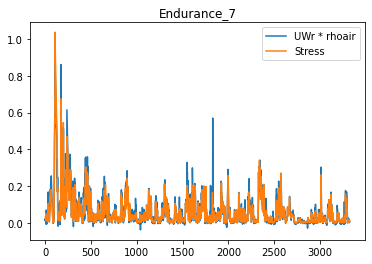

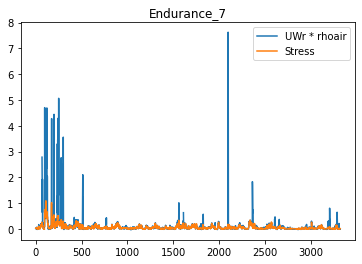

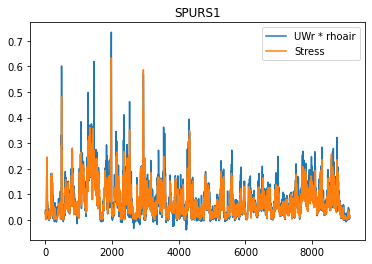

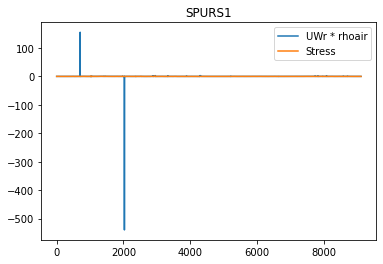

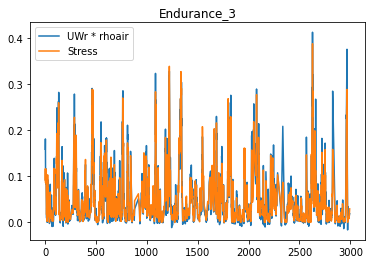

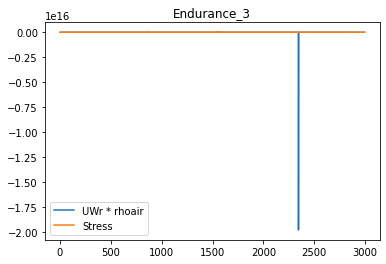

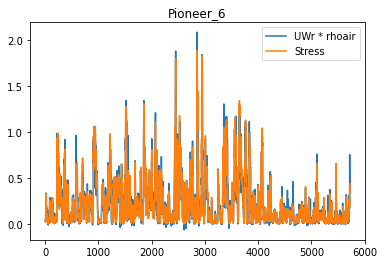

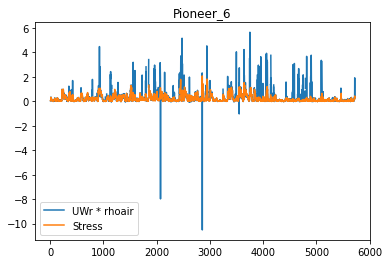

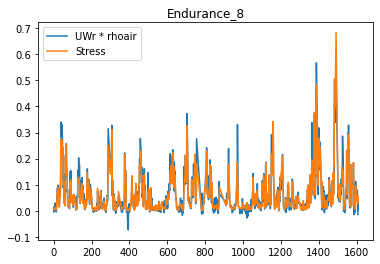

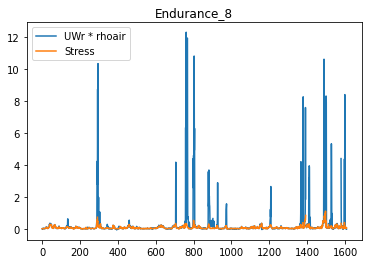

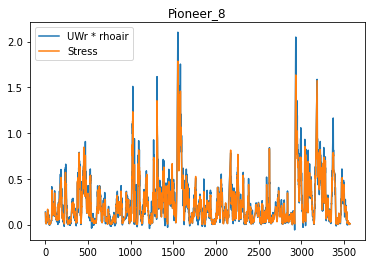

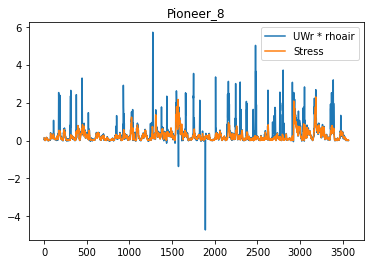

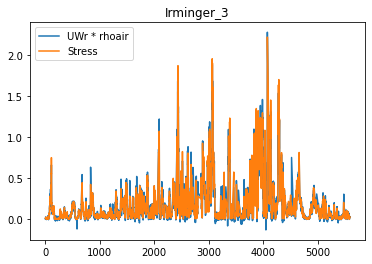

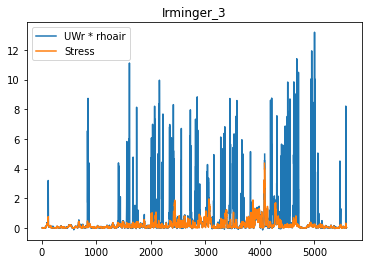

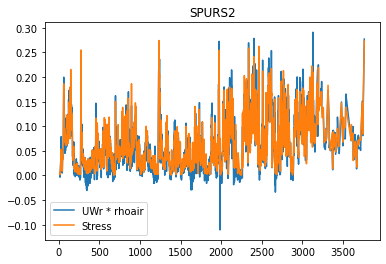

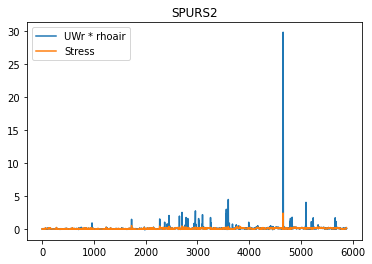

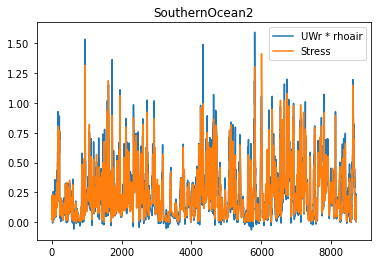

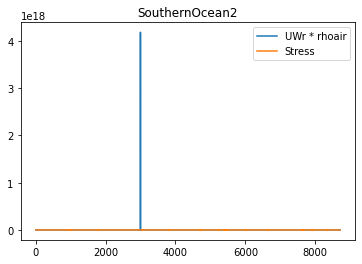

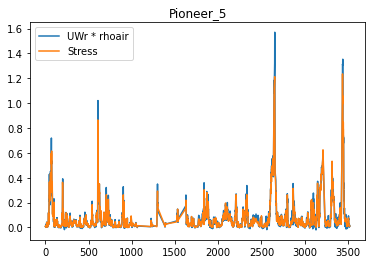

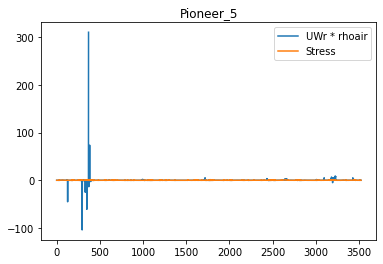

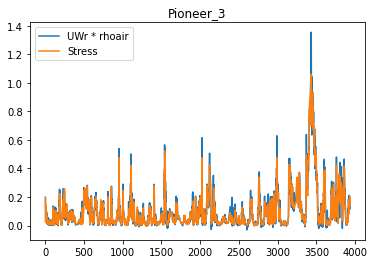

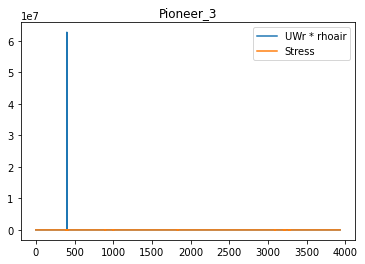

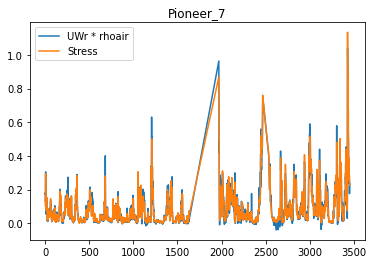

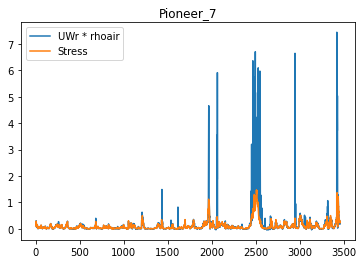

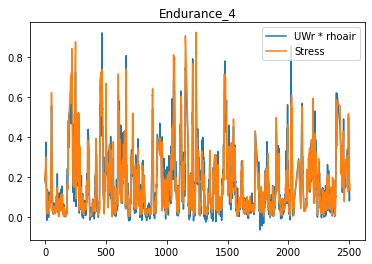

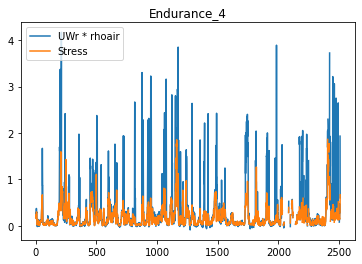

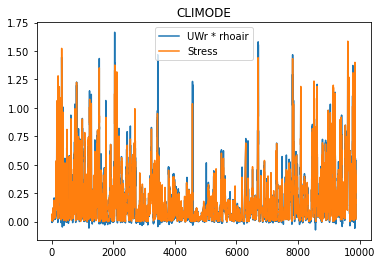

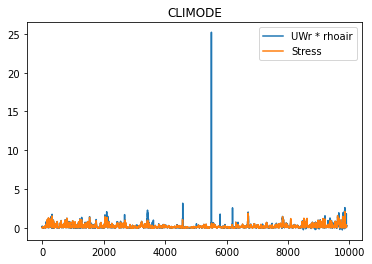

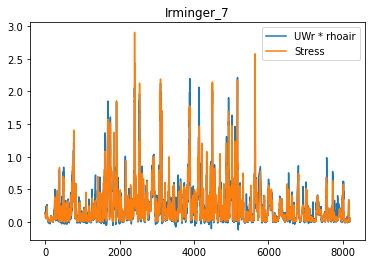

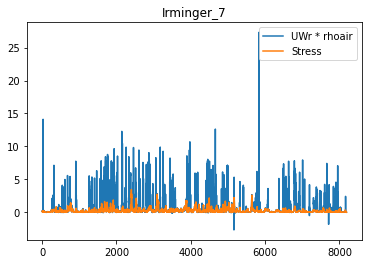

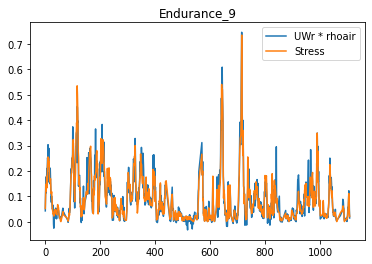

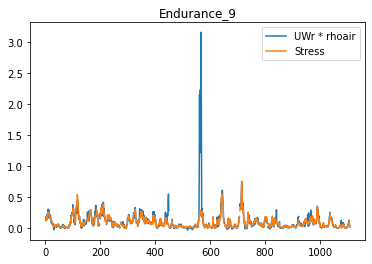

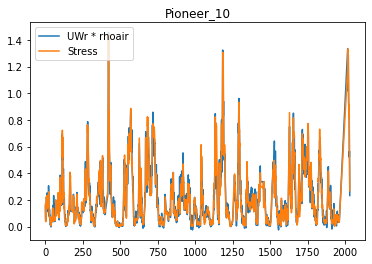

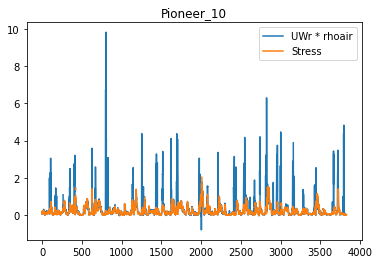

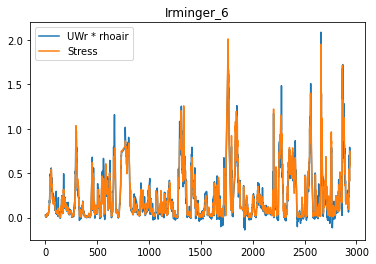

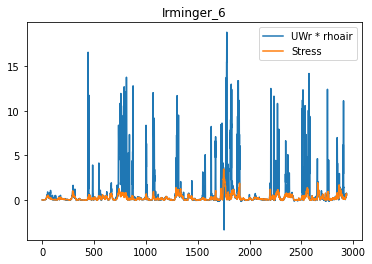

In [10]:
# for each of the datasets, do some data cleanup
# if quality flag entries for which:
# - SBytes != 0
# - any column is inf
# - any column is larger than 1e8
# - any column is close to 9999
# - UW is smaller than some given bounds
# - UW is larger than some given bounds

for crrt_dataset in dict_all_Transfer_files:
    #ic(crrt_dataset)
    time.sleep(0.5)

    crrt_pd = dict_all_Transfer_files[crrt_dataset]

    # valid rows by default
    validity_flag = np.ones((len(crrt_pd.index),), dtype=bool)

    # if find any reason why the row looks bad, invalid it
    for index, row in tqdm.tqdm(crrt_pd.iterrows(), total=len(crrt_pd.index)):

        # NOTE: here are the validity conditions; is it ok to remove the far tails?
        if \
            row["Sbytes"] != 0 or \
            (not np.all(np.isfinite((row[predictors].to_numpy().astype(np.float32))))) or \
            (np.any(row[predictors].to_numpy().astype(np.float32) > 1.0e8)) or \
            (np.any(np.abs(np.real(row[predictors].to_numpy()).astype(np.float32) - 9999.) < 1)) or \
            (row['UW'] < -2.0) or \
            (row['UW'] > 0.2) or \
            (row['UWr'] < -2.0) or \
            (row['UWr'] > 0.2):

            validity_flag[index] = 0

    # add information
    crrt_pd["valid_flag"] = validity_flag
    crrt_pd_valid = crrt_pd.loc[crrt_pd['valid_flag'] == True]
    
    path_strings = str(crrt_dataset).split('.')[0].split('_')
    if path_strings[-1].isnumeric(): 
        buoy = path_strings[-2] + '_' + path_strings[-1]
    else:
        buoy = path_strings[-1]
    print(np.sum(validity_flag), validity_flag.shape)
    plt.figure()
    plt.plot(- crrt_pd_valid['UWr'] * crrt_pd_valid['rhoair'], label='UWr * rhoair')
    plt.plot(crrt_pd_valid['stress'], label='Stress')
    plt.legend()
    plt.title(buoy)
    
    plt.figure()
    plt.plot(- crrt_pd['UWr'] * crrt_pd['rhoair'], label='UWr * rhoair')
    plt.plot(crrt_pd['stress'], label='Stress')
    plt.legend()
    plt.title(buoy)

In [11]:
crrt_dataset

PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Irminger_6.mat')

In [12]:
crrt_pd

,CE,CN,IR,Lv,P10,Pair,Q10,Qair,RH,RH10,...,sigHDir,stress,ustar,yday,yyyy,datetime,lat,lon,datetime_rounded,valid_flag
0,0.058741,0.083610,339.925002,2474.768030,1017.944242,1019.167502,7.248714,7.267303,93.933302,94.014437,...,106.608233,0.023803,0.138781,223.007639,2019,2019-08-11 00:10:59.996491,59.9337,-39.47378,2019-08-11 00:00:00,True
1,0.110629,0.096598,297.949997,2475.081231,1017.797864,1019.020508,7.268667,7.284779,93.525552,93.591409,...,101.552518,0.017449,0.118826,223.049306,2019,2019-08-11 01:10:59.999656,59.9337,-39.47378,2019-08-11 01:00:00,True
2,0.139019,0.126999,348.530000,2475.050118,1017.764995,1018.986008,7.469067,7.480979,93.906953,93.964349,...,98.317455,0.010006,0.089936,223.090972,2019,2019-08-11 02:11:00.000769,59.9337,-39.47378,2019-08-11 02:00:00,True
3,0.187421,0.070342,337.279997,2475.037386,1017.700083,1018.920502,7.588145,7.597242,94.722052,94.793354,...,101.308285,0.006871,0.074493,223.132639,2019,2019-08-11 03:10:59.998945,59.9337,-39.47378,2019-08-11 03:00:00,True
4,0.140239,0.010441,327.305002,2475.172549,1017.320471,1018.540506,7.613828,7.622443,95.132553,95.198827,...,106.933136,0.007151,0.075996,223.174306,2019,2019-08-11 04:10:59.997584,59.9337,-39.47378,2019-08-11 04:00:00,True
5,0.176854,-0.013473,329.375003,2475.265157,1017.184061,1018.404013,7.648043,7.654936,95.678902,95.761026,...,116.613900,0.009127,0.085828,223.215972,2019,2019-08-11 05:10:59.995659,59.9337,-39.47378,2019-08-11 05:00:00,True
6,0.145170,-0.041008,339.675003,2475.073387,1017.334882,1018.554507,7.713196,7.719129,95.807403,95.890642,...,83.804290,0.013978,0.106176,223.257639,2019,2019-08-11 06:11:00.004457,59.9337,-39.47378,2019-08-11 06:00:00,True
7,0.112314,-0.075428,330.885002,2474.972748,1017.275485,1018.495013,7.717048,7.723449,95.821753,95.915166,...,156.427439,0.023086,0.136408,223.299305,2019,2019-08-11 07:10:59.994647,59.9337,-39.47378,2019-08-11 07:00:00,True
8,0.110960,-0.085399,332.800002,2475.054486,1017.347608,1018.568494,7.501114,7.513557,94.857802,94.939535,...,149.940215,0.022781,0.135614,223.340972,2019,2019-08-11 08:10:59.995810,59.9337,-39.47378,2019-08-11 08:00:00,True
9,0.075299,-0.059982,337.259998,2475.169881,1017.499554,1018.718988,7.575346,7.590615,93.531353,93.423248,...,109.830997,0.017633,0.119237,223.382639,2019,2019-08-11 09:10:59.994821,59.9337,-39.47378,2019-08-11 09:00:00,True


In [13]:
for c in crrt_pd.columns:
    print(c)

CE
CN
IR
Lv
P10
Pair
Q10
Qair
RH
RH10
SSQ
SST
Sbytes
Solar
T10
Tair
Tm
Tp
Tsea
Tseasonic
Tsonic
U10e
U10r
UE
UEr
UN
UNr
UW
UWr
Ue
Ur
VW
VWr
WT
WTr
Wdir
Wdirr
cp
lhf
moL
mtime
rain
rhoair
shf
sigH
sigHDir
stress
ustar
yday
yyyy
datetime
lat
lon
datetime_rounded
valid_flag


# Get buoy name from the dict keys

In [14]:
d = dict_all_Transfer_files

In [15]:
buoys = []
for key in d.keys():
    path_strings = str(key).split('.')[0].split('_')
    if path_strings[-1].isnumeric(): 
        buoy = path_strings[-2] + '_' + path_strings[-1]
    else:
        buoy = path_strings[-1]
    buoys.append(buoy)
buoys

['Endurance_7',
 'SPURS1',
 'Endurance_3',
 'Pioneer_6',
 'Endurance_8',
 'Pioneer_8',
 'Irminger_3',
 'SPURS2',
 'SouthernOcean2',
 'Pioneer_5',
 'Pioneer_3',
 'Pioneer_7',
 'Endurance_4',
 'CLIMODE',
 'Irminger_7',
 'Endurance_9',
 'Pioneer_10',
 'Irminger_6']

In [16]:
d[key].keys()

Index(['CE', 'CN', 'IR', 'Lv', 'P10', 'Pair', 'Q10', 'Qair', 'RH', 'RH10',
       'SSQ', 'SST', 'Sbytes', 'Solar', 'T10', 'Tair', 'Tm', 'Tp', 'Tsea',
       'Tseasonic', 'Tsonic', 'U10e', 'U10r', 'UE', 'UEr', 'UN', 'UNr', 'UW',
       'UWr', 'Ue', 'Ur', 'VW', 'VWr', 'WT', 'WTr', 'Wdir', 'Wdirr', 'cp',
       'lhf', 'moL', 'mtime', 'rain', 'rhoair', 'shf', 'sigH', 'sigHDir',
       'stress', 'ustar', 'yday', 'yyyy', 'datetime', 'lat', 'lon',
       'datetime_rounded', 'valid_flag'],
      dtype='object')

In [17]:
key

PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Irminger_6.mat')

In [18]:
df_in_situ = d[key]
df_in_situ

,CE,CN,IR,Lv,P10,Pair,Q10,Qair,RH,RH10,...,sigHDir,stress,ustar,yday,yyyy,datetime,lat,lon,datetime_rounded,valid_flag
0,0.058741,0.083610,339.925002,2474.768030,1017.944242,1019.167502,7.248714,7.267303,93.933302,94.014437,...,106.608233,0.023803,0.138781,223.007639,2019,2019-08-11 00:10:59.996491,59.9337,-39.47378,2019-08-11 00:00:00,True
1,0.110629,0.096598,297.949997,2475.081231,1017.797864,1019.020508,7.268667,7.284779,93.525552,93.591409,...,101.552518,0.017449,0.118826,223.049306,2019,2019-08-11 01:10:59.999656,59.9337,-39.47378,2019-08-11 01:00:00,True
2,0.139019,0.126999,348.530000,2475.050118,1017.764995,1018.986008,7.469067,7.480979,93.906953,93.964349,...,98.317455,0.010006,0.089936,223.090972,2019,2019-08-11 02:11:00.000769,59.9337,-39.47378,2019-08-11 02:00:00,True
3,0.187421,0.070342,337.279997,2475.037386,1017.700083,1018.920502,7.588145,7.597242,94.722052,94.793354,...,101.308285,0.006871,0.074493,223.132639,2019,2019-08-11 03:10:59.998945,59.9337,-39.47378,2019-08-11 03:00:00,True
4,0.140239,0.010441,327.305002,2475.172549,1017.320471,1018.540506,7.613828,7.622443,95.132553,95.198827,...,106.933136,0.007151,0.075996,223.174306,2019,2019-08-11 04:10:59.997584,59.9337,-39.47378,2019-08-11 04:00:00,True
5,0.176854,-0.013473,329.375003,2475.265157,1017.184061,1018.404013,7.648043,7.654936,95.678902,95.761026,...,116.613900,0.009127,0.085828,223.215972,2019,2019-08-11 05:10:59.995659,59.9337,-39.47378,2019-08-11 05:00:00,True
6,0.145170,-0.041008,339.675003,2475.073387,1017.334882,1018.554507,7.713196,7.719129,95.807403,95.890642,...,83.804290,0.013978,0.106176,223.257639,2019,2019-08-11 06:11:00.004457,59.9337,-39.47378,2019-08-11 06:00:00,True
7,0.112314,-0.075428,330.885002,2474.972748,1017.275485,1018.495013,7.717048,7.723449,95.821753,95.915166,...,156.427439,0.023086,0.136408,223.299305,2019,2019-08-11 07:10:59.994647,59.9337,-39.47378,2019-08-11 07:00:00,True
8,0.110960,-0.085399,332.800002,2475.054486,1017.347608,1018.568494,7.501114,7.513557,94.857802,94.939535,...,149.940215,0.022781,0.135614,223.340972,2019,2019-08-11 08:10:59.995810,59.9337,-39.47378,2019-08-11 08:00:00,True
9,0.075299,-0.059982,337.259998,2475.169881,1017.499554,1018.718988,7.575346,7.590615,93.531353,93.423248,...,109.830997,0.017633,0.119237,223.382639,2019,2019-08-11 09:10:59.994821,59.9337,-39.47378,2019-08-11 09:00:00,True


In [19]:
df_in_situ['datetime'] = pd.to_datetime(df_in_situ['datetime'])
df_in_situ = df_in_situ.set_index('datetime')
df_in_situ

,CE,CN,IR,Lv,P10,Pair,Q10,Qair,RH,RH10,...,sigH,sigHDir,stress,ustar,yday,yyyy,lat,lon,datetime_rounded,valid_flag
datetime,,,,,,,,,,,,,,,,,,,,,
2019-08-11 00:10:59.996491,0.058741,0.083610,339.925002,2474.768030,1017.944242,1019.167502,7.248714,7.267303,93.933302,94.014437,...,1.21,106.608233,0.023803,0.138781,223.007639,2019,59.9337,-39.47378,2019-08-11 00:00:00,True
2019-08-11 01:10:59.999656,0.110629,0.096598,297.949997,2475.081231,1017.797864,1019.020508,7.268667,7.284779,93.525552,93.591409,...,1.06,101.552518,0.017449,0.118826,223.049306,2019,59.9337,-39.47378,2019-08-11 01:00:00,True
2019-08-11 02:11:00.000769,0.139019,0.126999,348.530000,2475.050118,1017.764995,1018.986008,7.469067,7.480979,93.906953,93.964349,...,1.12,98.317455,0.010006,0.089936,223.090972,2019,59.9337,-39.47378,2019-08-11 02:00:00,True
2019-08-11 03:10:59.998945,0.187421,0.070342,337.279997,2475.037386,1017.700083,1018.920502,7.588145,7.597242,94.722052,94.793354,...,1.20,101.308285,0.006871,0.074493,223.132639,2019,59.9337,-39.47378,2019-08-11 03:00:00,True
2019-08-11 04:10:59.997584,0.140239,0.010441,327.305002,2475.172549,1017.320471,1018.540506,7.613828,7.622443,95.132553,95.198827,...,1.02,106.933136,0.007151,0.075996,223.174306,2019,59.9337,-39.47378,2019-08-11 04:00:00,True
2019-08-11 05:10:59.995659,0.176854,-0.013473,329.375003,2475.265157,1017.184061,1018.404013,7.648043,7.654936,95.678902,95.761026,...,1.05,116.613900,0.009127,0.085828,223.215972,2019,59.9337,-39.47378,2019-08-11 05:00:00,True
2019-08-11 06:11:00.004457,0.145170,-0.041008,339.675003,2475.073387,1017.334882,1018.554507,7.713196,7.719129,95.807403,95.890642,...,1.00,83.804290,0.013978,0.106176,223.257639,2019,59.9337,-39.47378,2019-08-11 06:00:00,True
2019-08-11 07:10:59.994647,0.112314,-0.075428,330.885002,2474.972748,1017.275485,1018.495013,7.717048,7.723449,95.821753,95.915166,...,0.95,156.427439,0.023086,0.136408,223.299305,2019,59.9337,-39.47378,2019-08-11 07:00:00,True
2019-08-11 08:10:59.995810,0.110960,-0.085399,332.800002,2475.054486,1017.347608,1018.568494,7.501114,7.513557,94.857802,94.939535,...,0.95,149.940215,0.022781,0.135614,223.340972,2019,59.9337,-39.47378,2019-08-11 08:00:00,True


In [20]:
df_in_situ.index[0]

Timestamp('2019-08-11 00:10:59.996491')

# ERA5

In [21]:
data_dir_era5 = '/lustre/storeB/project/IT/geout/machine-ocean/data_raw/era5_buoys/'

## Eample

In [22]:
file = 'era_u10m_Irminger_6.nc'
era5 = xr.open_dataset(data_dir_era5 + file)
era5['u10'].sel(
        {
        'time':'2020-01-22 07:11:00.006928', 
        'latitude':59.9337, 
        'longitude':-39.47378
        },
        method='nearest'
        )

<xarray.DataArray 'u10' ()>
array(12.343186, dtype=float32)
Coordinates:
    longitude  float32 -39.4735
    latitude   float32 59.934
    time       datetime64[ns] 2020-01-22T07:00:00
Attributes:
    units:      m s**-1
    long_name:  10 metre U wind component

# Import normalized ASCAT metadata dict

In [23]:
data_dir = "/lustre/storeB/project/IT/geout/machine-ocean/data_raw/metop/"

In [24]:
import pickle5 as pickle

In [25]:
# When running for the first time
with open('../../../in_situ_obs_ascat_with_customisations.pickle', 'rb') as handle:
        ascat_dict = pickle.load(handle)
        
with open(data_dir + 'in_situ_obs_with_gridded_ascat_params_9000_images_stress_map.pickle', 'wb') as handle:
    pickle.dump(ascat_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

ModuleNotFoundError: No module named 'eumdac'

In [24]:
with open(data_dir + 'in_situ_obs_with_gridded_ascat_params_9000_images_cnn.pickle', 'rb') as handle:
    ascat_dict = pickle.load(handle)

In [25]:
ascat_dict.keys()

dict_keys(['Endurance_8', 'Irminger_7', 'SPURS2', 'Endurance_4', 'Irminger_6', 'Pioneer_5', 'CLIMODE', 'Endurance_9', 'Pioneer_10', 'SouthernOcean2', 'Endurance_3', 'Pioneer_3', 'SPURS1', 'Endurance_7', 'Irminger_3', 'Pioneer_7', 'Pioneer_6', 'Pioneer_8'])

In [26]:
ascat_dict['SPURS1'].keys()

dict_keys(['datetime_start', 'datetime_end', 'type', 'lat', 'lon', 'nc_data_location', 'products', 'nc_files'])

In [27]:
ascat_dict['Pioneer_3']['nc_files']['ASCA_SZR_1B_M01_20151023010000Z_20151023024158Z_N_O_20151023014637Z']

'ASCATL1SZR_20151023T010000Z_20151023T024158Z_epct_d458fe47_P.nc'

In [28]:
ascat_dict['Pioneer_3'].keys()

dict_keys(['datetime_start', 'datetime_end', 'type', 'lat', 'lon', 'nc_data_location', 'products', 'nc_files'])

ascat_dict['Irminger_6']['ascat_params']

ascat_dict['Pioneer_3']['ascat_params']

In [29]:
ascat_dict['Pioneer_3']['lat']

[40.1334]

In [30]:
ascat_dict['Irminger_3']['products']

<class 'eumdac.collection.SearchResults'>(EO:EUM:DAT:METOP:ASCSZR1B, {'publication': None, 'dtstart': '2016-07-10T12:11:00.011105+00:00', 'set': None, 'bbox': None, 'orbit': None, 'type': None, 'sat': None, 'sort': None, 'title': None, 't6': None, 'geo': 'POINT(-39.4738 59.9337)', 'dtend': '2017-08-14T01:11:59.949652+00:00', 'zone': None})

In [31]:
for product, fname in ascat_dict['Pioneer_3']['nc_files'].items():
    print(fname)

ASCATL1SZR_20151023T010000Z_20151023T024158Z_epct_d458fe47_P.nc
ASCATL1SZR_20151022T145100Z_20151022T163258Z_epct_d55bf5b6_P.nc
ASCATL1SZR_20151022T135700Z_20151022T153558Z_epct_82855dc8_P.nc
ASCATL1SZR_20151021T233600Z_20151022T012058Z_epct_f94cadfe_P.nc
ASCATL1SZR_20151021T151200Z_20151021T165058Z_epct_42b5f330_P.nc
ASCATL1SZR_20151021T004500Z_20151021T022658Z_epct_891fb4fe_P.nc
ASCATL1SZR_20151021T000000Z_20151021T014158Z_epct_8b2bcdcc_P.nc
ASCATL1SZR_20151020T135400Z_20151020T153258Z_epct_57f6ecb6_P.nc
ASCATL1SZR_20151019T150000Z_20151019T163858Z_epct_fbc8cd2e_P.nc
ASCATL1SZR_20151019T141500Z_20151019T155358Z_epct_709cee11_P.nc
ASCATL1SZR_20151019T004200Z_20151019T022358Z_epct_eefbf552_P.nc
ASCATL1SZR_20151018T234500Z_20151019T012658Z_epct_958c3d38_P.nc
ASCATL1SZR_20151018T010300Z_20151018T024458Z_epct_feeb1040_P.nc
ASCATL1SZR_20151017T145400Z_20151017T163558Z_epct_0f085316_P.nc
ASCATL1SZR_20151017T140000Z_20151017T153858Z_epct_e954376f_P.nc
ASCATL1SZR_20151016T234200Z_20151017T012

# 1) Fill in ASCAT dict with params

In [32]:
import sys
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [34]:
count = 0
for buoy in ascat_dict.keys():
    station_lat = ascat_dict[buoy]['lat'][0]
    station_lon = ascat_dict[buoy]['lon'][0]
    print(buoy)
    if 'ascat_params' not in ascat_dict[buoy].keys():
                ascat_dict[buoy]['ascat_params'] = {}
            
    if 'nc_files' in ascat_dict[buoy].keys():
        for product, fname in ascat_dict[buoy]['nc_files'].items():
                try:
                    ascat_param_dict = ascat.ascat_params_cnn(
                        ascat_fn = data_dir + fname,
                        station_lon=station_lon,
                        station_lat=station_lat,
                        nx=3,
                        ny=3
                    )
                    ascat_dict[buoy]['ascat_params'][product] = ascat_param_dict
                except:
                    print('Data from buoy ', buoy, 'File ', fname, ' cannot be extracted. ') # Check if the image exists and if the crop area is within the image
                    count = count - 1                 
                
print('Number of images that were not cropped: ', count)

Endurance_8
Irminger_7
SPURS2
Endurance_4
Irminger_6
Pioneer_5
CLIMODE
Endurance_9
Pioneer_10
SouthernOcean2
Endurance_3
Pioneer_3
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150913T140300Z_20150913T154458Z_epct_b258c7fc_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150912T234500Z_20150913T012658Z_epct_392f3166_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150822T150000Z_20150822T163858Z_epct_ad13fa21_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150822T141500Z_20150822T155358Z_epct_4928a410_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150822T004200Z_20150822T022358Z_epct_91f90e57_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150821T234500Z_20150822T012658Z_epct_59c3b003_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCATL1SZR_20150821T010300Z_20150821T024458Z_epct_596f2f9e_P.nc  cannot be extracted. 
Data from buoy  Pioneer_3 File  ASCA

In [37]:
ascat_dict['Pioneer_5']['nc_files']['ASCA_SZR_1B_M02_20161015150900Z_20161015165058Z_N_O_20161015164912Z']

'ASCATL1SZR_20161015T150900Z_20161015T165058Z_epct_66c59a71_P.nc'

In [38]:
ascat_dict['Pioneer_5']['ascat_params']['ASCA_SZR_1B_M02_20161015150900Z_20161015165058Z_N_O_20161015164912Z']

{'grid_lats_orig': array([ 8.89512481e+01,  8.84954770e+01,  8.80397059e+01,  8.75839348e+01,
         8.71281637e+01,  8.66723927e+01,  8.62166216e+01,  8.57608505e+01,
         8.53050794e+01,  8.48493083e+01,  8.43935372e+01,  8.39377662e+01,
         8.34819951e+01,  8.30262240e+01,  8.25704529e+01,  8.21146818e+01,
         8.16589108e+01,  8.12031397e+01,  8.07473686e+01,  8.02915975e+01,
         7.98358264e+01,  7.93800553e+01,  7.89242843e+01,  7.84685132e+01,
         7.80127421e+01,  7.75569710e+01,  7.71011999e+01,  7.66454288e+01,
         7.61896578e+01,  7.57338867e+01,  7.52781156e+01,  7.48223445e+01,
         7.43665734e+01,  7.39108024e+01,  7.34550313e+01,  7.29992602e+01,
         7.25434891e+01,  7.20877180e+01,  7.16319469e+01,  7.11761759e+01,
         7.07204048e+01,  7.02646337e+01,  6.98088626e+01,  6.93530915e+01,
         6.88973204e+01,  6.84415494e+01,  6.79857783e+01,  6.75300072e+01,
         6.70742361e+01,  6.66184650e+01,  6.61626940e+01,  6.57069229

with open(data_dir + 'in_situ_obs_with_gridded_ascat_params_9000_images_cnn.pickle', 'wb') as handle:
    pickle.dump(ascat_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Merge in situ obs and ASCAT data

empty dict for new dfs

For each key in d:

    get buoy name
    get df for that buoy
    add empty cols for s0, inc, az
    for each product
        find closest timestamp in df to (beginposition+(endposition-startposition))/2
        fill in that row with sar params
    remove rows with nans
    save df with matches in new dict



    df['sigma0_trip_fore'] = np.nan
    df['sigma0_trip_mid'] = np.nan
    df['sigma0_trip_aft'] = np.nan
    df['azi_angle_trip_fore'] = np.nan
    df['azi_angle_trip_mid'] = np.nan
    df['azi_angle_trip_aft'] = np.nan
    df['inc_angle_trip_fore'] = np.nan 
    df['inc_angle_trip_mid'] = np.nan 
    df['inc_angle_trip_aft'] = np.nan
    

In [25]:
# Dict with in situ data from WHOI
for key, df in d.items():
    print(key)

/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Endurance_7.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_SPURS1.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Endurance_3.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Pioneer_6.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Endurance_8.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Pioneer_8.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Irminger_3.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_SPURS2.mat
/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_SouthernOcean2.mat
/lus

In [26]:
key

PosixPath('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Irminger_6.mat')

In [27]:
d[Path('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Pioneer_5.mat')]

,CE,CN,IR,Lv,P10,Pair,Q10,Qair,RH,RH10,...,sigHDir,stress,ustar,yday,yyyy,datetime,lat,lon,datetime_rounded,valid_flag
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,126.274571,NaN,NaN,134.548611,2016,2016-05-13 13:10:00.019424,40.1334,-70.7785,2016-05-13 13:00:00,False
1,-0.091070,-0.073820,337.374997,2474.740549,1012.082085,1013.282993,9.333997,9.105735,97.035900,96.930874,...,110.444721,0.009357,0.087466,134.590278,2016,2016-05-13 14:09:59.986278,40.1334,-70.7785,2016-05-13 14:00:00,True
2,-0.098521,-0.026441,339.770000,2474.092254,1011.688030,1012.887503,9.498990,9.278976,97.549050,97.562895,...,98.091869,0.012114,0.099567,134.631944,2016,2016-05-13 15:09:59.927263,40.1334,-70.7785,2016-05-13 15:00:00,True
3,-0.140713,0.044838,333.190001,2474.220118,1010.779282,1011.976492,9.685306,9.420608,97.287700,97.187676,...,175.833866,0.010733,0.093814,134.673611,2016,2016-05-13 16:09:59.981765,40.1334,-70.7785,2016-05-13 16:00:00,True
4,-0.141269,0.095732,342.544998,2472.916964,1010.138787,1011.335489,9.462316,9.296000,96.187849,96.018364,...,180.950234,0.011033,0.095139,134.715278,2016,2016-05-13 17:10:00.032496,40.1334,-70.7785,2016-05-13 17:00:00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,108.394639,NaN,NaN,289.673611,2016,2016-10-15 16:09:59.991291,40.1334,-70.7785,2016-10-15 16:00:00,False
3569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,109.218653,NaN,NaN,289.715278,2016,2016-10-15 17:10:00.058658,40.1334,-70.7785,2016-10-15 17:00:00,False
3570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,289.756945,2016,2016-10-15 18:10:00.032493,40.1334,-70.7785,2016-10-15 18:00:00,False
3571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,337.414751,NaN,NaN,289.798610,2016,2016-10-15 19:09:59.942598,40.1334,-70.7785,2016-10-15 19:00:00,False


In [28]:
df_in_situ = d[Path('/lustre/storeB/project/IT/geout/machine-ocean/prepared_datasets/in_situ_data_WHOI/WHOI/Transfer_Pioneer_5.mat')]
df_in_situ = df_in_situ.loc[df_in_situ['valid_flag'] == True]
df_in_situ['datetime'] = pd.to_datetime(df_in_situ['datetime'])
df_in_situ = df_in_situ.set_index('datetime')

/tmp/ipykernel_4024059/2095981431.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_in_situ['datetime'] = pd.to_datetime(df_in_situ['datetime'])


In [29]:
df_in_situ.index

DatetimeIndex(['2016-05-13 14:09:59.986278', '2016-05-13 15:09:59.927263',
               '2016-05-13 16:09:59.981765', '2016-05-13 17:10:00.032496',
               '2016-05-13 18:09:59.889625', '2016-05-13 19:09:59.968981',
               '2016-05-13 20:10:00.007964', '2016-05-13 21:09:59.942391',
               '2016-05-13 22:09:59.969022', '2016-05-13 23:09:59.962098',
               ...
               '2016-10-13 05:10:00.023906', '2016-10-13 07:09:59.985678',
               '2016-10-13 08:09:59.934559', '2016-10-13 09:09:59.981175',
               '2016-10-13 10:09:59.979392', '2016-10-13 11:09:59.989708',
               '2016-10-13 12:10:00.015856', '2016-10-13 13:09:59.990406',
               '2016-10-13 15:10:00.033740', '2016-10-13 17:09:59.982969'],
              dtype='datetime64[ns]', name='datetime', length=2479, freq=None)

In [30]:
buoy = 'Pioneer_5'
product = 'ASCA_SZR_1B_M01_20161006003600Z_20161006022058Z_N_O_20161006012631Z'

In [31]:
beginposition = ascat_dict[buoy]['ascat_params'][product]['start_sensing_time']
endposition = ascat_dict[buoy]['ascat_params'][product]['stop_sensing_time']

beginposition = beginposition.replace('Z', '.')
beginposition = datetime.strptime(beginposition.split('.')[0],'%Y%m%dT%H%M%S')  

endposition = endposition.replace('Z', '.')
endposition = datetime.strptime(endposition.split('.')[0],'%Y%m%dT%H%M%S')

In [32]:
beginposition 


datetime.datetime(2016, 10, 6, 0, 36)

In [33]:
beginposition - timedelta(minutes=30)

datetime.datetime(2016, 10, 6, 0, 6)

In [34]:
endposition

datetime.datetime(2016, 10, 6, 2, 20, 58)

In [35]:
endposition + timedelta(minutes=30)

datetime.datetime(2016, 10, 6, 2, 50, 58)

In [36]:
mask = (df_in_situ.index > beginposition - timedelta(minutes=30)) & (df_in_situ.index <= endposition + timedelta(minutes=30))
df_begin_end = df_in_situ.loc[mask]
df_begin_end

,CE,CN,IR,Lv,P10,Pair,Q10,Qair,RH,RH10,...,sigH,sigHDir,stress,ustar,yday,yyyy,lat,lon,datetime_rounded,valid_flag
datetime,,,,,,,,,,,,,,,,,,,,,
2016-10-06 00:09:59.995237,-0.253209,-0.065330,384.210001,2448.456421,1022.900286,1024.094006,10.027824,10.240187,82.05645,81.380519,...,2.65,133.410283,0.098515,0.286401,280.006944,2016,40.1334,-70.7785,2016-10-06 00:00:00,True
2016-10-06 02:10:00.025335,-0.244082,0.097213,383.869998,2448.759881,1022.877666,1024.071515,10.139746,10.336001,83.10225,82.519568,...,2.39,134.615008,0.084585,0.265508,280.090278,2016,40.1334,-70.7785,2016-10-06 02:00:00,True


In [37]:
list_of_params = [
        'sigma0_trip_fore', 'sigma0_trip_mid', 'sigma0_trip_aft',
        'azi_angle_trip_fore', 'azi_angle_trip_mid', 'azi_angle_trip_aft',
        'inc_angle_trip_fore', 'inc_angle_trip_mid', 'inc_angle_trip_aft',
        'start_sensing_time',
        'stop_sensing_time'
    ]

In [95]:
count = 0
collocated_dict = {}
for key, df in d.items(): # One dict per buoy
    buoy = buoys[count]
    
    # Load in situ data
    df_in_situ = d[key]
    df_in_situ = df_in_situ.loc[df_in_situ['valid_flag'] == True]
    df_in_situ['datetime'] = pd.to_datetime(df_in_situ['datetime'])
    df_in_situ = df_in_situ.set_index('datetime')
    
    # Load ERA5 data
    u_file = 'era_u10m_' + buoy + '.nc'
    v_file = 'era_v10m_' + buoy + '.nc'
    u10_dataset = xr.open_dataset(data_dir_era5 + u_file)
    v10_dataset = xr.open_dataset(data_dir_era5 + v_file)
    
    for parameter in (list_of_params + ['u10', 'v10']):
        df_in_situ[parameter] = np.nan
    
    for product in ascat_dict[buoy]['ascat_params']:
        beginposition = ascat_dict[buoy]['ascat_params'][product]['start_sensing_time']        
        beginposition = beginposition.replace('Z', '.')
        beginposition = datetime.strptime(beginposition.split('.')[0],'%Y%m%dT%H%M%S')  
        
        endposition = ascat_dict[buoy]['ascat_params'][product]['stop_sensing_time']
        endposition = endposition.replace('Z', '.')
        endposition = datetime.strptime(endposition.split('.')[0],'%Y%m%dT%H%M%S')  
        
        # TODO:
        # We need to get all the observations between start - 30 min <= date <= end + 30 min
        #greater than the start date and smaller than the end date
        mask = (df_in_situ.index > beginposition - timedelta(minutes=20)) & (df_in_situ.index <= endposition + timedelta(minutes=20))
        df_begin_end = df_in_situ.loc[mask]
        timestamps = df_begin_end.index
        
        for parameter in list_of_params:
            # Fill in with ASCAT params
            for timestamp in timestamps:
                df_in_situ.loc[df_in_situ.index==timestamp, parameter] = ascat_dict[buoy]['ascat_params'][product][parameter]
            
        # Fill in with ERA5 data
        for timestamp in timestamps:
            df_in_situ.loc[df_in_situ.index==timestamp, 'u10']  = u10_dataset['u10'].sel(
                {
                'time':timestamp, 
                'latitude':df_in_situ['lat'][0], 
                'longitude':df_in_situ['lon'][0]
                },
                method='nearest'
                ).values
            
            
            
            # Fill in with ERA5 data
            df_in_situ.loc[df_in_situ.index==timestamp, 'v10'] = v10_dataset['v10'].sel(
                {
                'time':timestamp, 
                'latitude':df_in_situ['lat'][0], 
                'longitude':df_in_situ['lon'][0]
                },
                method='nearest'
                ).values
    
    df_in_situ = df_in_situ.replace([-np.inf], np.nan)
    df_in_situ = df_in_situ.dropna(subset=['sigma0_trip_fore', 'sigma0_trip_mid', 'sigma0_trip_aft'])
    collocated_dict[buoy] = df_in_situ
    print(count)             
    count = count + 1

/tmp/ipykernel_4024059/2450523835.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_in_situ['datetime'] = pd.to_datetime(df_in_situ['datetime'])


ValueError: Must have equal len keys and value when setting with an ndarray

In [39]:
df_in_situ.loc[df_in_situ.index==timestamp, parameter]

datetime
2018-08-30 18:41:59.955070   NaN
Name: sigma0_trip_fore, dtype: float64

In [41]:
ascat_dict[buoy]['ascat_params'][product][parameter].shape

(7, 7)

In [42]:
collocated_dict[buoy]

KeyError: 'Endurance_7'

In [52]:
nx=7#17
ny=7#17

In [53]:
num_pixels = nx*ny

In [62]:
list_num_pixels = list(range(num_pixels))

list_of_params_extended = [
        'sigma0_trip_fore', 'sigma0_trip_mid', 'sigma0_trip_aft',
        'azi_angle_trip_fore', 'azi_angle_trip_mid', 'azi_angle_trip_aft',
        'inc_angle_trip_fore', 'inc_angle_trip_mid', 'inc_angle_trip_aft',
        #'start_sensing_time','stop_sensing_time',
        'lats_cropped_image', 'lons_cropped_image',
        'u10', 'v10'
    ]

dict_of_column_names = {}
new_columns = []
for param in list_of_params_extended:
    columns = [param + '_' + str(n) for n in list_num_pixels]
    dict_of_column_names[param] = columns
    new_columns.append(columns)

In [63]:
def add_empty_columns(df, columns):
    for col in columns:
        df[col] = np.nan
    return df

In [64]:
def fill_in_row(df, timestamp, columns, data):
    for count, col in enumerate(columns):
        df_in_situ.loc[df.index==timestamp, col] = data[count]
    return df 

In [65]:
def make_1xn_rows(row, n):
    full_row = np.array(np.full([n, ], 9999))
    full_row[:len(row)] = row
    return full_row

In [66]:
type(np.nanmean(np.nan)) == float


/tmp/ipykernel_4024059/2622835693.py:1: RuntimeWarning: Mean of empty slice
  type(np.nanmean(np.nan)) == float


False

In [ ]:
buoys = [
    'Endurance_7',
     'SPURS1',
     'Endurance_3',
     'Pioneer_6',
     'Endurance_8',
     'Pioneer_8',
     'Irminger_3',
     'SPURS2',
     'SouthernOcean2',
     'Pioneer_5',
     'Pioneer_3',
     'Pioneer_7',
     'Endurance_4',
     'CLIMODE',
     'Irminger_7',
     'Endurance_9',
     'Pioneer_10',
     'Irminger_6'
]

In [130]:
buoys = [
    'Endurance_7',
     'SPURS1',
     'Endurance_3',
     'Pioneer_6',
     'Endurance_8',
     'Pioneer_8',
     'Irminger_3',
     'SPURS2',
     'SouthernOcean2',
     'Pioneer_5',
     'Pioneer_3',
     'Pioneer_7',
     'Endurance_4',
     'CLIMODE',
     'Irminger_7',
     'Endurance_9',
     'Pioneer_10',
     'Irminger_6'
]

for buoy in buoys:
    if (buoy != 'SPURS1') & (buoy != 'SPURS2'):
        print(buoy)

Endurance_7
Endurance_3
Pioneer_6
Endurance_8
Pioneer_8
Irminger_3
SouthernOcean2
Pioneer_5
Pioneer_3
Pioneer_7
Endurance_4
CLIMODE
Irminger_7
Endurance_9
Pioneer_10
Irminger_6


Endurance_7
0
SPURS1
SPURS variable
1
Endurance_3
2
Pioneer_6
3
Endurance_8
4
Pioneer_8
5
Irminger_3
6
SPURS2
SPURS variable
7
SouthernOcean2
8
Pioneer_5
9
Pioneer_3
10
Pioneer_7
11
Endurance_4
12
CLIMODE
13
Irminger_7
14
Endurance_9
15
Pioneer_10
16
Irminger_6
17


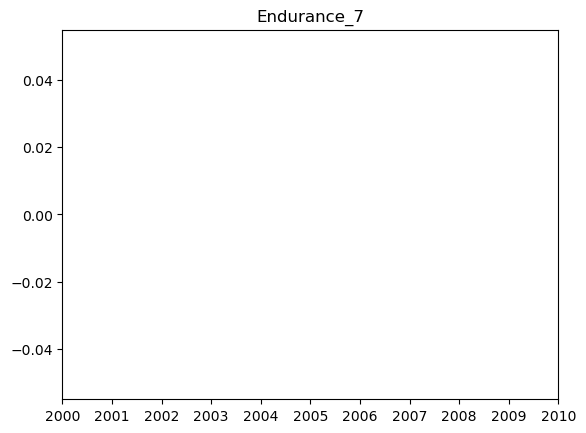

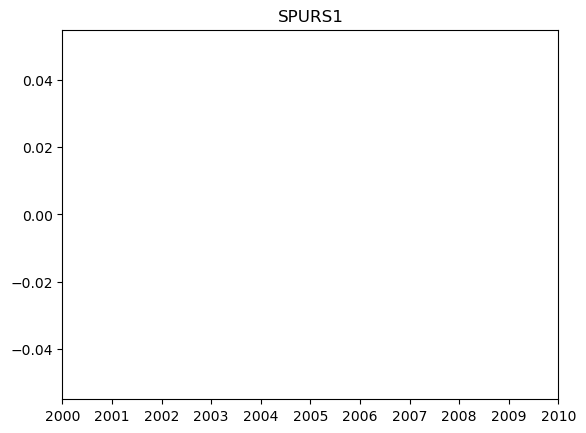

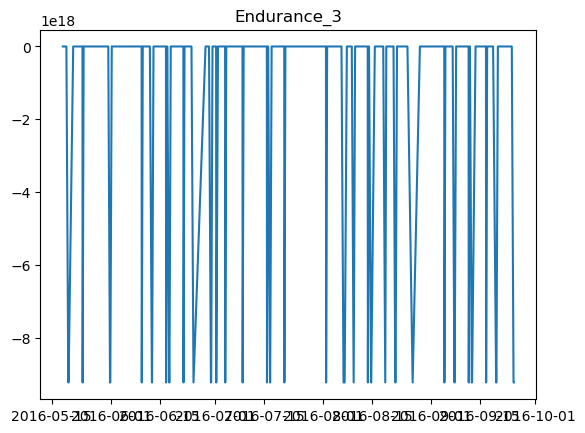

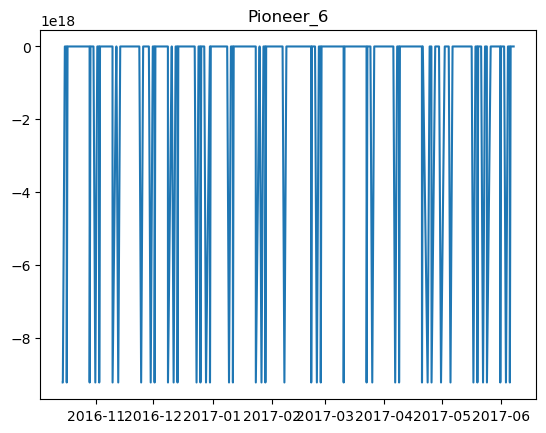

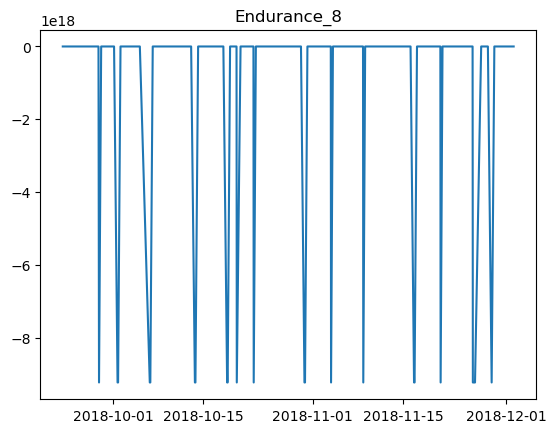

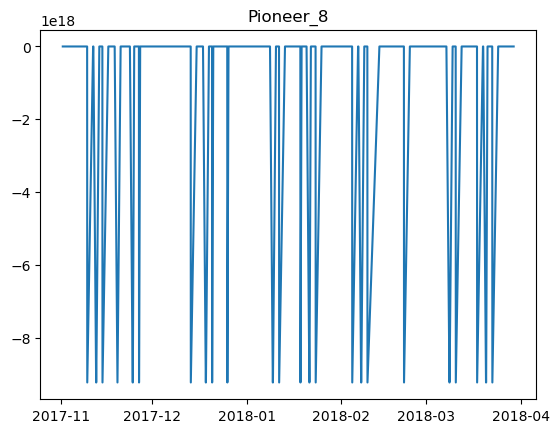

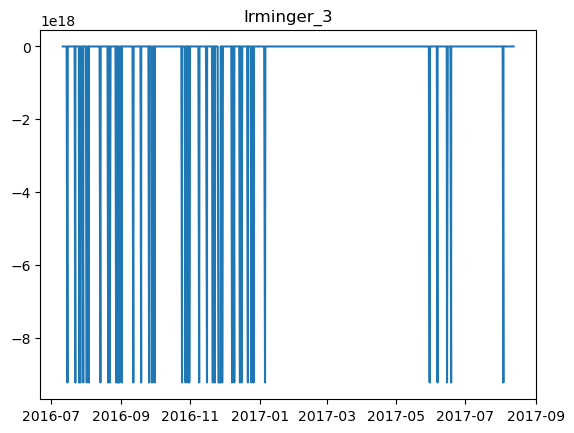

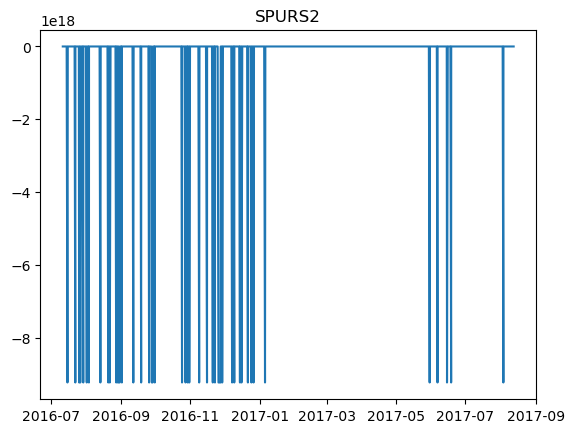

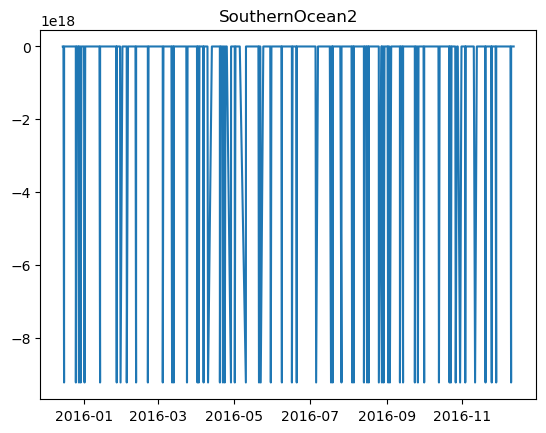

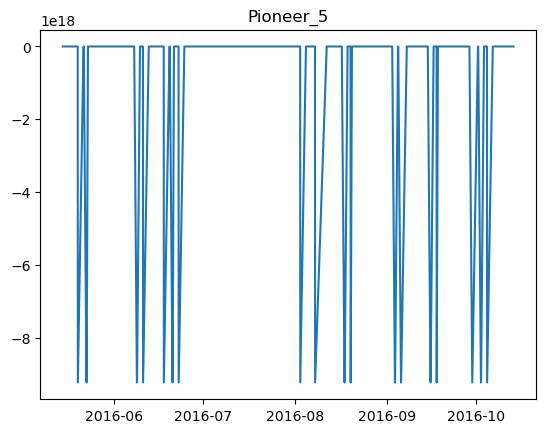

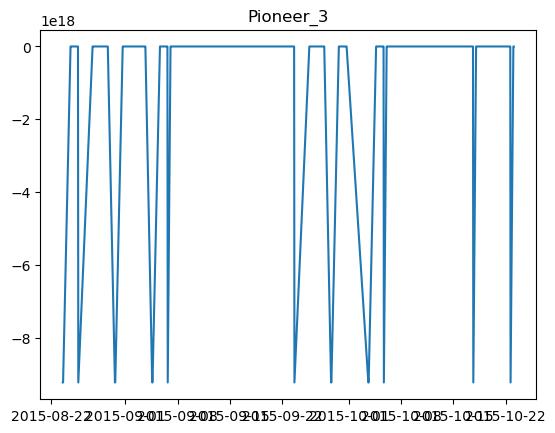

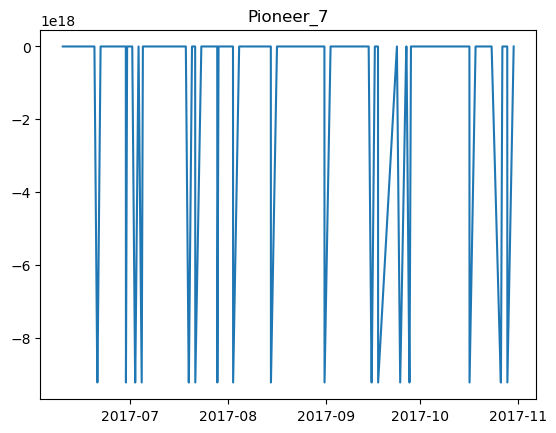

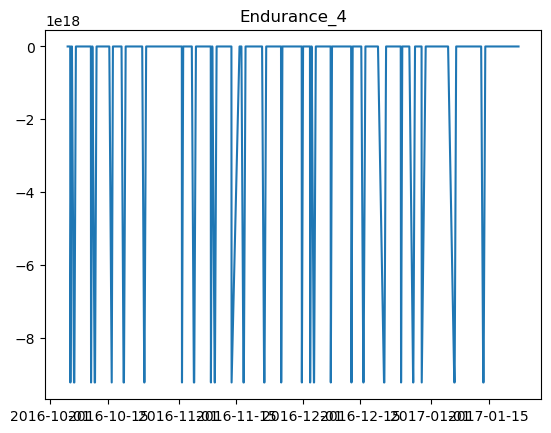

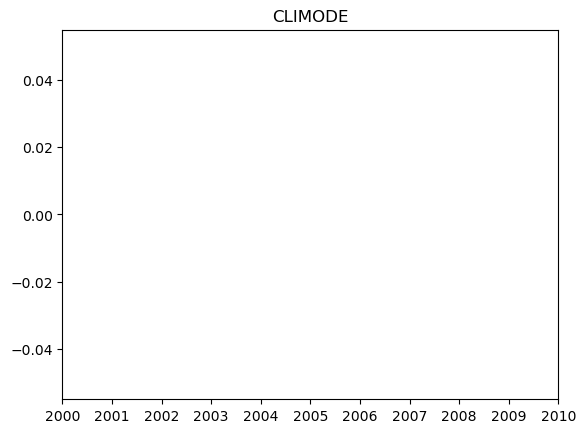

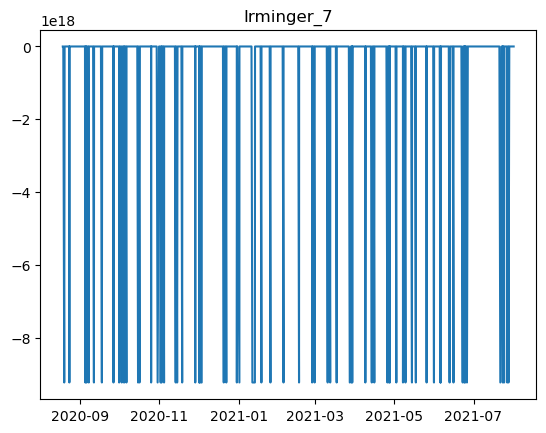

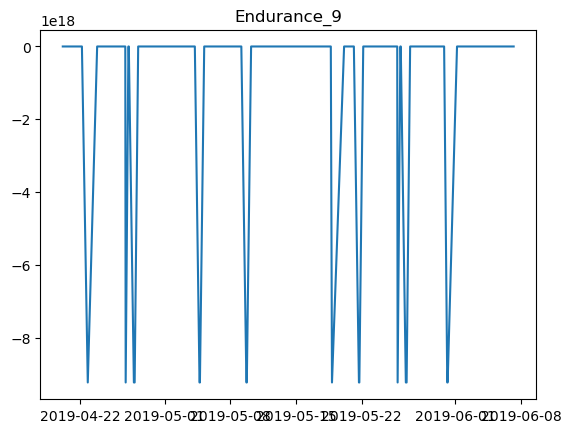

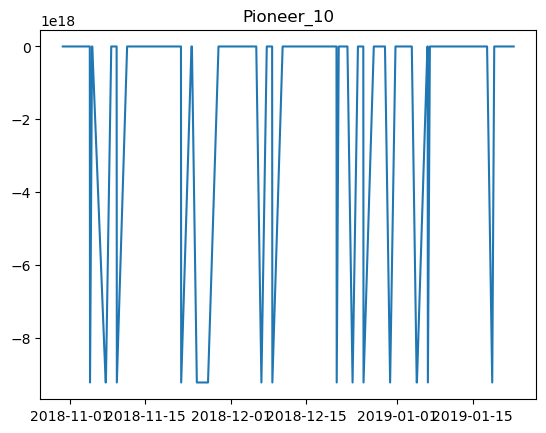

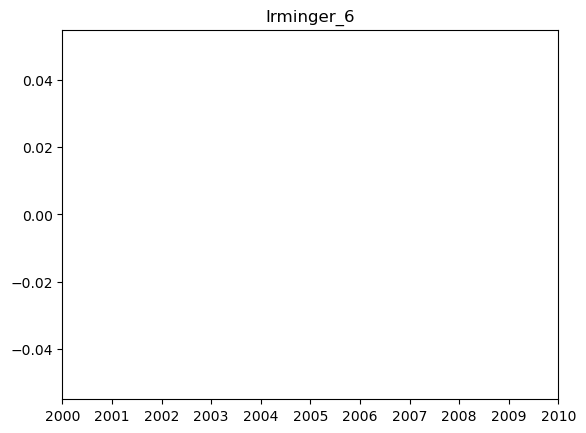

In [134]:
count = 0
collocated_dict = {}

first_iter = True
for key, df in d.items():
    df = add_empty_columns(df, new_columns)
    buoy = buoys[count]
    print(buoy)
    if (buoy != 'SPURS1') & (buoy != 'SPURS2'):
        df_in_situ = d[key]
        df_in_situ = df_in_situ.loc[df_in_situ['valid_flag'] == True]
        df_in_situ['datetime'] = pd.to_datetime(df_in_situ['datetime'])
        df_in_situ = df_in_situ.set_index('datetime')
        timestamps = []

        # Load ERA5 data
        u_file = 'era_u10m_' + buoy + '.nc'
        v_file = 'era_v10m_' + buoy + '.nc'
        u10_dataset = xr.open_dataset(data_dir_era5 + u_file)
        v10_dataset = xr.open_dataset(data_dir_era5 + v_file)

        for product in ascat_dict[buoy]['ascat_params']:
            beginposition = ascat_dict[buoy]['ascat_params'][product]['start_sensing_time']        
            beginposition = beginposition.replace('Z', '.')
            beginposition = datetime.strptime(beginposition.split('.')[0],'%Y%m%dT%H%M%S')  

            endposition = ascat_dict[buoy]['ascat_params'][product]['stop_sensing_time']
            endposition = endposition.replace('Z', '.')
            endposition = datetime.strptime(endposition.split('.')[0],'%Y%m%dT%H%M%S') 

            # TODO:
            # We need to get all the observations between start - 30 min <= date <= end + 30 min
            #greater than the start date and smaller than the end date
            mask = (df_in_situ.index > beginposition - timedelta(minutes=20)) & (df_in_situ.index <= endposition + timedelta(minutes=20))
            df_begin_end = df_in_situ.loc[mask]
            timestamps = df_begin_end.index

            lon_ascat = ascat_dict[buoy]['ascat_params'][product]['lons_cropped_image']
            lat_ascat = ascat_dict[buoy]['ascat_params'][product]['lats_cropped_image']
            grid_lon_ascat, grid_lat_ascat = np.meshgrid(lon_ascat, lat_ascat)
            grid_lon_era5_u, grid_lat_era5_u = np.meshgrid(u10_dataset['longitude'], u10_dataset['latitude'])
            grid_lon_era5_v, grid_lat_era5_v = np.meshgrid(v10_dataset['longitude'], v10_dataset['latitude'])


            # Fill in with ASCAT params
            for timestamp in timestamps:
                    list_of_parameterst_t = []
                    for parameter in list_of_params_extended:

                        if parameter == 'u10':
                            u10_station = u10_dataset['u10'].sel(time=timestamp, method='nearest')
                            regridded_arr = griddata(
                                (grid_lat_era5_u.flatten(), grid_lon_era5_u.flatten()), 
                               u10_station.values.flatten(), 
                                (grid_lat_ascat, grid_lon_ascat), 
                                method='linear'
                            )
                            parameter_t = regridded_arr.flatten()
                        elif parameter == 'v10':
                            v10_station = v10_dataset['v10'].sel(time=timestamp, method='nearest')
                            regridded_arr = griddata(
                                (grid_lat_era5_v.flatten(), grid_lon_era5_v.flatten()), 
                                v10_station.values.flatten(), 
                                (grid_lat_ascat, grid_lon_ascat), 
                                method='linear'
                            )
                            parameter_t = regridded_arr.flatten()
                            parameter_t = make_1xn_rows(parameter_t, num_pixels)
                        else:
                            parameter_t = ascat_dict[buoy]['ascat_params'][product][parameter].flatten()
                            parameter_t = make_1xn_rows(parameter_t, num_pixels)

                        list_of_parameterst_t.append(parameter_t)
                    ascat_row = np.concatenate(list_of_parameterst_t)
                    df_in_situ = fill_in_row(df_in_situ, timestamp, new_columns, ascat_row)
                    #df_in_situ.loc[df_in_situ.index==timestamp, parameter] = ascat_dict[buoy]['ascat_params'][product][parameter]


                #TODO: CONTINUE HERE!!!
    else:
        print('SPURS variable')
        
    df_in_situ = df_in_situ.replace([-np.inf], np.nan)
    df_in_situ = df_in_situ.dropna(subset=new_columns)
    collocated_dict[buoy] = df_in_situ
    print(count)             
    count = count + 1
    
    plt.figure()
    plt.plot(df_in_situ[[new_columns[0]]])
    plt.title(buoy)

    
    

In [91]:
v10_dataset['v10'].sel(time=timestamp, method='nearest')

<xarray.DataArray 'v10' (latitude: 41, longitude: 41)>
array([[-3.110925, -2.667117, -2.319334, ...,  0.37498 ,  0.170829, -0.127732],
       [-3.034267, -2.825274, -2.52752 , ..., -0.265716, -0.302835, -0.534421],
       [-2.633227, -2.421813, -2.207978, ..., -0.795864, -0.704682, -0.545718],
       ...,
       [-1.7908  , -1.821463, -1.941694, ...,  0.062701, -0.152747, -0.243122],
       [-2.046594, -2.227345, -2.38066 , ...,  0.273308, -0.315745, -0.405314],
       [-2.153108, -2.379046, -2.60095 , ...,  0.717922,  0.075612, -0.134995]],
      dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -129.3 -129.1 -128.8 ... -119.8 -119.6 -119.3
  * latitude   (latitude) float32 49.64 49.39 49.14 48.89 ... 40.14 39.89 39.64
    time       datetime64[ns] 2018-08-30T19:00:00
Attributes:
    units:      m s**-1
    long_name:  10 metre V wind component

In [83]:
u10_dataset['u10'].values.flatten().shape

(1972800,)

In [90]:
v10_station

<xarray.DataArray 'v10' (latitude: 41, longitude: 41)>
array([[-3.110925, -2.667117, -2.319334, ...,  0.37498 ,  0.170829, -0.127732],
       [-3.034267, -2.825274, -2.52752 , ..., -0.265716, -0.302835, -0.534421],
       [-2.633227, -2.421813, -2.207978, ..., -0.795864, -0.704682, -0.545718],
       ...,
       [-1.7908  , -1.821463, -1.941694, ...,  0.062701, -0.152747, -0.243122],
       [-2.046594, -2.227345, -2.38066 , ...,  0.273308, -0.315745, -0.405314],
       [-2.153108, -2.379046, -2.60095 , ...,  0.717922,  0.075612, -0.134995]],
      dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -129.3 -129.1 -128.8 ... -119.8 -119.6 -119.3
  * latitude   (latitude) float32 49.64 49.39 49.14 48.89 ... 40.14 39.89 39.64
    time       datetime64[ns] 2018-08-30T19:00:00
Attributes:
    units:      m s**-1
    long_name:  10 metre V wind component

In [84]:
grid_lat_era5.shape

(5, 5)

In [79]:
 era5['u10'].values.flatten().shape

(1972800,)

In [71]:
u10_dataset['u10']

<xarray.DataArray 'u10' (time: 78912, latitude: 5, longitude: 5)>
[1972800 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -124.8 -124.6 -124.3 -124.1 -123.8
  * latitude   (latitude) float32 45.14 44.89 44.64 44.39 44.14
  * time       (time) datetime64[ns] 2012-01-01 ... 2020-12-31T23:00:00
Attributes:
    units:      m s**-1
    long_name:  10 metre U wind component

In [77]:
u10_dataset['u10'].sel(time=timestamp, method='nearest')

/home/paulinast/.conda/envs/mlstormsurge/lib/python3.9/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


<xarray.DataArray 'u10' (latitude: 5, longitude: 5)>
array([[1.285293, 0.771832, 1.225467, 1.29691 , 0.649275],
       [1.160993, 0.64637 , 1.243473, 1.396814, 0.602808],
       [1.28297 , 0.795065, 1.46361 , 1.604173, 0.71549 ],
       [1.532149, 1.178419, 1.766808, 1.812114, 0.958281],
       [1.811533, 1.442119, 1.516467, 1.543185, 1.127305]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -124.8 -124.6 -124.3 -124.1 -123.8
  * latitude   (latitude) float32 45.14 44.89 44.64 44.39 44.14
    time       datetime64[ns] 2018-08-30T19:00:00
Attributes:
    units:      m s**-1
    long_name:  10 metre U wind component

In [61]:
parameter

'start_sensing_time'

In [60]:
ascat_dict[buoy]['ascat_params'][product][parameter]

'20180830T183000Z'

In [51]:
ascat_dict[buoy]['ascat_params'][product][parameter].shape

(7, 7)

In [55]:
collocated_dict['Pioneer_7'][['UWr', 'rhoair', 'sigma0_trip_fore', 'u10', 'v10']]

,UWr,rhoair,sigma0_trip_fore,u10,v10
datetime,,,,,
2017-06-09 15:11:00.013167,-0.108552,1.213399,-23.606268,8.010723,-1.526059
2017-06-09 16:11:00.017771,-0.149502,1.213591,-23.606268,8.366278,0.692337
2017-06-10 14:11:00.033378,-0.013028,1.219626,-27.670694,5.166289,1.848653
2017-06-10 15:11:00.035909,-0.019739,1.220326,-27.670694,5.109544,2.156077
2017-06-11 01:12:00.010394,-0.051168,1.210728,-23.581158,5.572124,5.995786
...,...,...,...,...,...
2017-10-28 15:12:00.010730,-0.017372,1.214561,-26.016972,1.395977,4.168236
2017-10-28 16:12:00.028720,-0.013269,1.212989,-19.373363,1.196293,4.596158
2017-10-29 01:11:59.980169,-0.118747,1.204730,-24.191271,-2.139453,7.332076


In [56]:
collocated_dict['Irminger_3'][['UWr', 'rhoair', 'sigma0_trip_fore', 'u10', 'v10']]

,UWr,rhoair,sigma0_trip_fore,u10,v10
datetime,,,,,
2016-07-10 22:11:00.002925,-0.016792,1.256439,-27.038279,-2.566008,1.626250
2016-07-10 23:11:00.012195,-0.023148,1.256706,-27.038279,-2.596338,1.365124
2016-07-11 12:10:59.985949,-0.008453,1.258117,-26.535995,-2.105626,0.999984
2016-07-11 13:11:00.003236,-0.007296,1.257028,-26.535995,-1.809334,1.005803
2016-07-11 14:10:59.983016,-0.003911,1.255727,-26.535995,-1.701237,0.841418
...,...,...,...,...,...
2017-08-11 23:11:59.980186,-0.061721,1.245206,-30.524120,-0.501289,5.509682
2017-08-12 00:11:59.981048,-0.026354,1.245716,-30.524120,-0.324758,5.442036
2017-08-12 12:11:59.989959,-0.001817,1.241915,-31.923285,-0.985001,-1.199584


with open(data_dir + 'collocated_dict_ascat_9000_images_era5_cnn_7_7_without_spurs.pickle', 'wb') as handle:
    pickle.dump(collocated_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Collocate ERA5 and observations in time